# Chapter 10 Lab: Inference, Capacity, Cost, and SLOs

**Runtime:** 2–3 minutes · **Difficulty:** intermediate · **Credentials:** none

Model quality is only one production dimension. This notebook combines illustrative
serving configurations with queueing pressure, cost, memory, and a quality floor to select
feasible deployment candidates.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/10_inference_and_capacity.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/10_inference_and_capacity.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- distinguish service latency from queueing latency;
- identify unstable load configurations;
- build a multi-constraint service-level objective;
- calculate a quality–cost–latency Pareto frontier; and
- stress a chosen configuration under a load spike.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab.plotting import COLORS, finish, set_finance_theme

set_finance_theme()
configs = pd.read_csv(ROOT / "data" / "infrastructure_configs.csv")
configs.head()


,configuration,precision,batch_size,quality_index,service_rate_rps,p95_latency_ms,cost_per_1k_requests_usd,memory_index,data_status
0,fp32-b1,fp32,1,1.000,5.2000,255.000,3.4000,1.00,illustrative benchmark
1,fp32-b4,fp32,4,1.000,12.2823,360.000,2.0929,1.00,illustrative benchmark
2,fp32-b16,fp32,16,1.000,29.0107,780.000,1.2884,1.00,illustrative benchmark
3,fp32-b32,fp32,32,1.000,44.5858,1340.000,1.0108,1.00,illustrative benchmark
4,fp16-b1,fp16,1,0.998,8.5800,154.545,1.9720,0.58,illustrative benchmark


## 1. Add queueing delay

For an M/M/1 teaching approximation, waiting time becomes unstable when arrival rate
reaches service rate. The queue-wait tail satisfies
`P(W_q > t) = utilization × exp(-(service-arrival)t)`. We add that wait estimate to the
measured no-queue service p95 as a conservative screening approximation.


In [3]:
arrival_rate = 10.0

def queue_wait_p95_ms(arrival: float, service: float) -> float:
    if arrival >= service:
        return np.inf
    utilization = arrival / service
    if utilization <= 0.05:
        return 0.0
    return float(np.log(utilization / 0.05) / (service - arrival) * 1000)

configs["utilization"] = arrival_rate / configs["service_rate_rps"]
configs["stable"] = configs["utilization"] < 1
configs["queue_p95_ms"] = [
    queue_wait_p95_ms(arrival_rate, service)
    for service in configs["service_rate_rps"]
]
configs["total_p95_ms"] = configs["p95_latency_ms"] + configs["queue_p95_ms"]
configs[
    [
        "configuration",
        "quality_index",
        "service_rate_rps",
        "utilization",
        "total_p95_ms",
        "cost_per_1k_requests_usd",
        "stable",
    ]
].replace(np.inf, np.nan).round(3)


,configuration,quality_index,service_rate_rps,utilization,total_p95_ms,cost_per_1k_requests_usd,stable
0,fp32-b1,1.000,5.200,1.923,NaN,3.400,False
1,fp32-b4,1.000,12.282,0.814,1582.520,2.093,True
2,fp32-b16,1.000,29.011,0.345,881.556,1.288,True
3,fp32-b32,1.000,44.586,0.224,1383.396,1.011,True
4,fp16-b1,0.998,8.580,1.166,NaN,1.972,False
5,fp16-b4,0.998,20.266,0.493,441.193,1.214,True
6,fp16-b16,0.998,47.868,0.209,510.487,0.747,True
7,fp16-b32,0.998,73.566,0.136,827.855,0.586,True
8,int8-b1,0.991,11.700,0.855,1783.173,1.156,True
9,int8-b4,0.991,27.635,0.362,272.232,0.712,True


## 2. Apply the production SLO


In [4]:
quality_floor = 0.985
latency_ceiling = 1_250
cost_ceiling = 2.25
configs["quality_pass"] = configs["quality_index"] >= quality_floor
configs["latency_pass"] = configs["total_p95_ms"] <= latency_ceiling
configs["cost_pass"] = configs["cost_per_1k_requests_usd"] <= cost_ceiling
configs["slo_pass"] = configs[["stable", "quality_pass", "latency_pass", "cost_pass"]].all(axis=1)
feasible = configs[configs["slo_pass"]].sort_values(
    ["cost_per_1k_requests_usd", "total_p95_ms"]
)
feasible[
    ["configuration", "quality_index", "total_p95_ms", "cost_per_1k_requests_usd", "memory_index"]
].round(3)


,configuration,quality_index,total_p95_ms,cost_per_1k_requests_usd,memory_index
11,int8-b32,0.991,603.195,0.344,0.34
10,int8-b16,0.991,366.925,0.438,0.34
7,fp16-b32,0.998,827.855,0.586,0.58
9,int8-b4,0.991,272.232,0.712,0.34
6,fp16-b16,0.998,510.487,0.747,0.58
5,fp16-b4,0.998,441.193,1.214,0.58
2,fp32-b16,1.000,881.556,1.288,1.00


## 3. Compute the Pareto frontier


In [5]:
def dominated(row: pd.Series, frame: pd.DataFrame) -> bool:
    better_or_equal = (
        (frame["quality_index"] >= row["quality_index"])
        & (frame["total_p95_ms"] <= row["total_p95_ms"])
        & (frame["cost_per_1k_requests_usd"] <= row["cost_per_1k_requests_usd"])
    )
    strictly_better = (
        (frame["quality_index"] > row["quality_index"])
        | (frame["total_p95_ms"] < row["total_p95_ms"])
        | (frame["cost_per_1k_requests_usd"] < row["cost_per_1k_requests_usd"])
    )
    return bool((better_or_equal & strictly_better).any())

stable = configs[configs["stable"]].copy()
stable["pareto"] = [not dominated(row, stable) for _, row in stable.iterrows()]
stable[stable["pareto"]][
    ["configuration", "quality_index", "total_p95_ms", "cost_per_1k_requests_usd"]
].sort_values("cost_per_1k_requests_usd").round(3)


,configuration,quality_index,total_p95_ms,cost_per_1k_requests_usd
15,int4-b32,0.972,474.049,0.212
14,int4-b16,0.972,285.838,0.271
11,int8-b32,0.991,603.195,0.344
10,int8-b16,0.991,366.925,0.438
13,int4-b4,0.972,196.017,0.440
7,fp16-b32,0.998,827.855,0.586
9,int8-b4,0.991,272.232,0.712
6,fp16-b16,0.998,510.487,0.747
3,fp32-b32,1.000,1383.396,1.011
5,fp16-b4,0.998,441.193,1.214


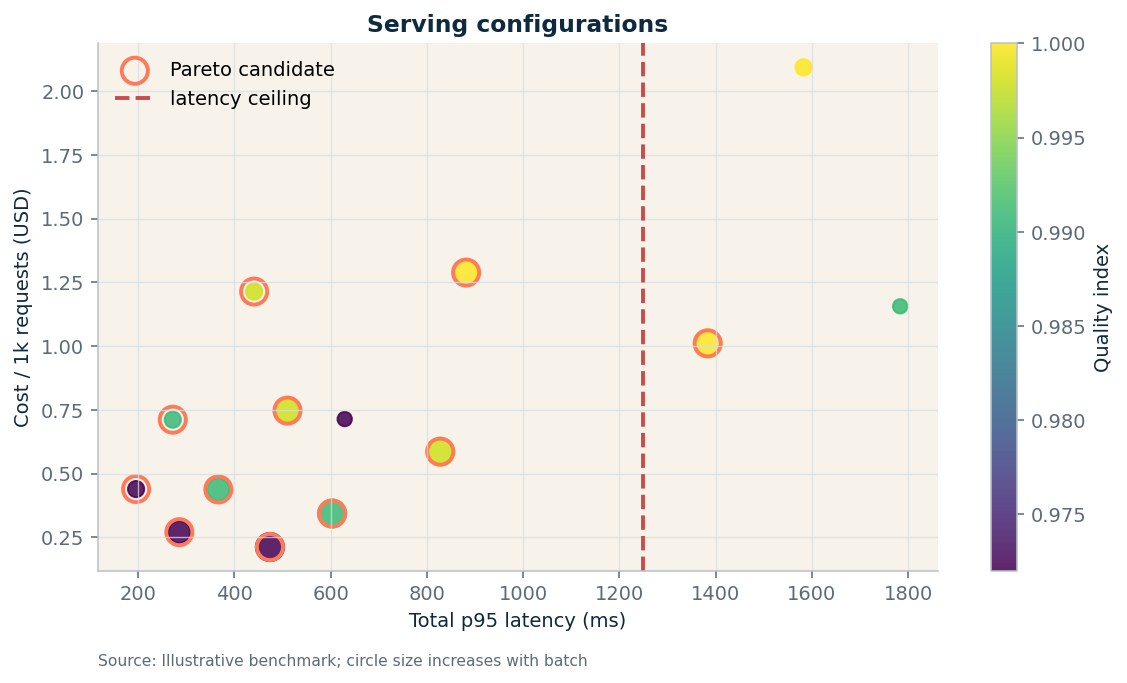

In [6]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
scatter = ax.scatter(
    stable["total_p95_ms"],
    stable["cost_per_1k_requests_usd"],
    c=stable["quality_index"],
    s=50 + stable["batch_size"] * 5,
    cmap="viridis",
    alpha=0.85,
)
pareto = stable[stable["pareto"]]
ax.scatter(
    pareto["total_p95_ms"],
    pareto["cost_per_1k_requests_usd"],
    facecolors="none",
    edgecolors=COLORS["coral"],
    s=180,
    linewidths=2,
    label="Pareto candidate",
)
ax.axvline(latency_ceiling, color=COLORS["red"], linestyle="--", label="latency ceiling")
ax.set(title="Serving configurations", xlabel="Total p95 latency (ms)", ylabel="Cost / 1k requests (USD)")
fig.colorbar(scatter, ax=ax, label="Quality index")
ax.legend()
finish(ax, "Illustrative benchmark; circle size increases with batch")
plt.tight_layout()


## 4. Stress the best feasible candidate


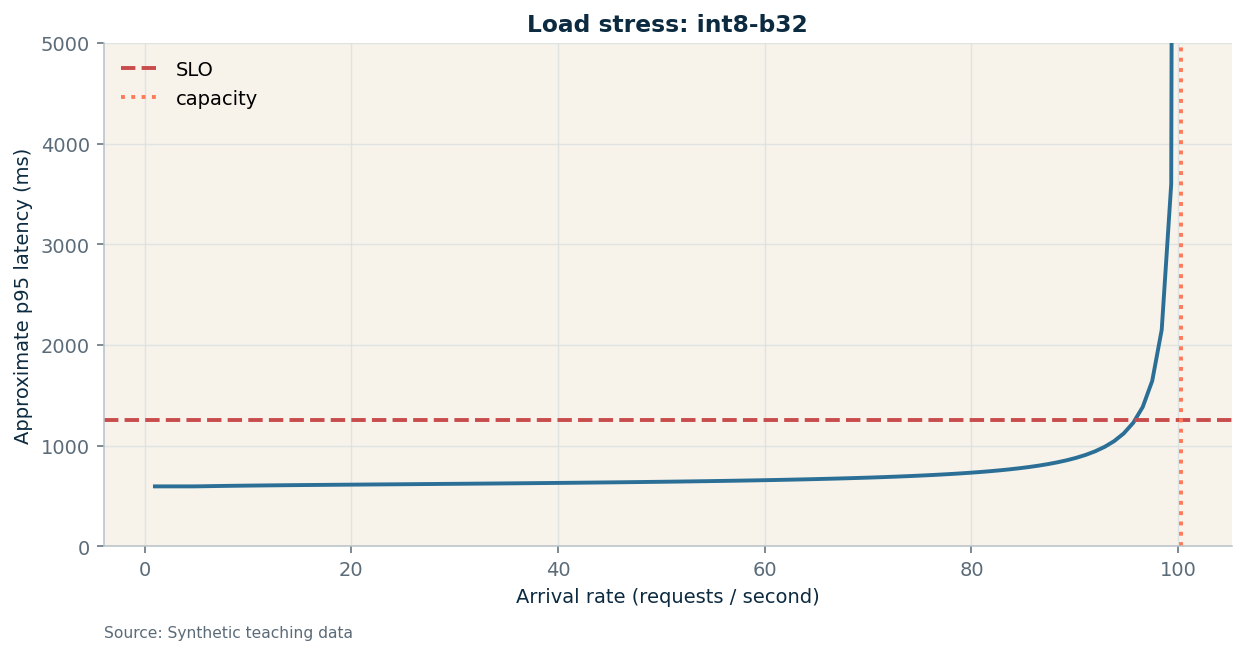

In [7]:
if feasible.empty:
    raise RuntimeError("No configuration satisfies the declared SLO")
selected = feasible.iloc[0]
loads = np.linspace(1, selected["service_rate_rps"] * 1.10, 120)
stress_latency = np.array(
    [
        selected["p95_latency_ms"]
        + queue_wait_p95_ms(load, selected["service_rate_rps"])
        for load in loads
    ]
)
fig, ax = plt.subplots()
finite = np.isfinite(stress_latency)
ax.plot(loads[finite], stress_latency[finite], color=COLORS["blue"])
ax.axhline(latency_ceiling, color=COLORS["red"], linestyle="--", label="SLO")
ax.axvline(selected["service_rate_rps"], color=COLORS["coral"], linestyle=":", label="capacity")
ax.set(
    title=f"Load stress: {selected['configuration']}",
    xlabel="Arrival rate (requests / second)",
    ylabel="Approximate p95 latency (ms)",
    ylim=(0, min(5000, np.nanmax(stress_latency[finite]))),
)
ax.legend()
finish(ax)
plt.tight_layout()


## 5. Deployment decision record


In [8]:
decision = {
    "selected_configuration": selected["configuration"],
    "arrival_rate_rps": arrival_rate,
    "quality_floor": quality_floor,
    "latency_ceiling_ms": latency_ceiling,
    "cost_ceiling_usd_per_1k": cost_ceiling,
    "observed_quality": float(selected["quality_index"]),
    "estimated_total_p95_ms": float(selected["total_p95_ms"]),
    "estimated_cost_usd_per_1k": float(selected["cost_per_1k_requests_usd"]),
    "caveat": (
        "Illustrative M/M/1 queue-wait screen with conservative p95 addition; "
        "validate the total-latency distribution with workload replay."
    ),
}
decision


{'arrival_rate_rps': 10.0,
 'caveat': 'Illustrative M/M/1 queue-wait screen with conservative p95 addition; validate the '
           'total-latency distribution with workload replay.',
 'cost_ceiling_usd_per_1k': 2.25,
 'estimated_cost_usd_per_1k': 0.3437,
 'estimated_total_p95_ms': 603.1953656421346,
 'latency_ceiling_ms': 1250,
 'observed_quality': 0.991,
 'quality_floor': 0.985,
 'selected_configuration': 'int8-b32'}

## Takeaways

- A fast model can miss its SLO when the queue is unstable.
- Quantization and batching trade quality, memory, latency, and cost.
- Feasibility comes before scalar optimization.
- A production choice needs workload replay, tail measurements, and failure-mode tests.

**Challenge:** extend the model to two replicas with bursty arrivals and a 10-minute
autoscaling delay.
